<a href="https://colab.research.google.com/github/AnanyaSharma2900/Ecommerce-data-analysis/blob/main/ONLINE_SALES_DATA_ANALYSIS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **ONLINE SALES DATA ANALYSIS**

This project analyse on online sales dataset to understand sales performance, customer behavior, and key treads over time. The goal is to identify top-performing categories and products, analysis montly trends and detect issues such as cancellations and returns.

**IMPORT LIBRARIES**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


**LOAD ECOMMERCE SALES DATASET**

In [3]:
df = pd.read_csv('/content/drive/MyDrive/dataset/messy_ecommerce_sales_data.csv')
df.to_csv('/content/drive/MyDrive/dataset/messy_ecommerce_sales_data.csv', index=False)
df.head(10)

,ID,Customer_Name,Order_ID,Order_Date,Product,Category,Quantity,Price,Payment_Method,Status,Total
0,100,Customer_100,ORD-41285,11/22/2024,Blender,Home,3,38,Cash,shipped,114.00
1,101,Customer_101,ORD-35783,07-05-2025,Smartphone,Electronics,2,abd,PayPal,Processing,NaN
2,102,Customer_102,ORD-84355,12/23/2024,Tennis Racket,Sports,1,389.05,PayPal,Delivered,389.05
3,103,Customer_103,ORD-57811,3/19/2025,Science,Books,5,233.92,PayPal,Processing,1169.60
4,104,Customer_104,ORD-93614,10/20/2025,Biography,Books,1,552.51,Cash on Delivery,Processing,552.51
5,105,Customer_105,ORD-22442,11/20/2024,Tennis Racket,Sports,NaN,122.06,CASH,Cancelled,366.18
6,106,Customer_106,ORD-25885,02-02-2025,Blender,Home,NaN,978.63,Bank Transfer,Processing,NaN
7,107,Customer_107,ORD-89122,01-03-2025,Biography,Books,5,587.68,PayPal,Returned,2938.40
8,108,Customer_108,ORD-64400,10/23/2025,Science,Books,1,600.29,Cash on Delivery,Processing,600.29
9,109,Customer_109,ORD-18512,05-03-2025,Tennis Racket,Sports,5,168.34,Credit Card,shipped,841.70


**IDENTIFY THE PROBLEM IN DATASET**

 BASIC OVERVIEW

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 111 entries, 0 to 110
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   ID              111 non-null    int64  
 1    Customer_Name  111 non-null    object 
 2   Order_ID        111 non-null    object 
 3   Order_Date      111 non-null    object 
 4   Product         111 non-null    object 
 5    Category       101 non-null    object 
 6   Quantity        104 non-null    object 
 7   Price           106 non-null    object 
 8   Payment_Method  111 non-null    object 
 9   Status          111 non-null    object 
 10  Total           97 non-null     float64
dtypes: float64(1), int64(1), object(9)
memory usage: 9.7+ KB


NUMBER OF NULL VALUES

In [5]:
df.isnull().sum()

,0
ID,0
Customer_Name,0
Order_ID,0
Order_Date,0
Product,0
Category,10
Quantity,7
Price,5
Payment_Method,0
Status,0


NUMBER OF DUPLICATES

In [6]:
df.duplicated().sum()


np.int64(5)

IDENTIFYING CATEGORICAL COLUMNS AND DATA INCONSISTENCIES

In [7]:
for col in df.columns:
  if df[col].nunique()<20:
    print(df[col].value_counts())
    print("_"*50)

 Category
Home           20
Books          18
Sports         16
Clothing       12
Electronics    11
electronic      4
ELECTRONICS     4
Book            3
Cloth           3
Sport           2
electronics     2
BOOKS           2
sports          1
BOOk            1
SPORTS          1
clothing        1
Name: count, dtype: int64
__________________________________________________
Quantity
5        24
2        23
1        20
4        17
3        10
1000      1
-2        1
40        1
3333      1
-5        1
50000     1
4a        1
33        1
222       1
66        1
Name: count, dtype: int64
__________________________________________________
Payment_Method
Cash on Delivery    28
PayPal              27
Credit Card         26
Bank Transfer       19
Bank                 3
Cash                 2
CASH                 2
Bank TRANSFER        2
Cash on Del          2
Name: count, dtype: int64
__________________________________________________
Status
Returned      30
Processing    26
Shipped       22
Ca

**PROBLEM IDENTIFICATION**


1.   MISSING VALUES FOUND IN COLUMNS
2.   SAME PRODUCT HAS MULTIPLE PRICE VALUES
3.   DUPLICATE RECORD PRESENT
4.   COLUMN HAS IN CORRECT DATATYPE



# **DATA CLEANING AND PREPARATION**

**HANDLING THE 'CATEGORY' COLUMN**

In [8]:
df[' Category'].isnull().sum()

np.int64(10)

In [9]:
df[' Category'].value_counts()

,count
Category,
Home,20
Books,18
Sports,16
Clothing,12
Electronics,11
electronic,4
ELECTRONICS,4
Book,3
Cloth,3


In [10]:
df[' Category']=df[' Category'].str.strip().str.lower()
df[' Category'].value_counts()

,count
Category,
home,20
books,20
sports,18
electronics,17
clothing,13
electronic,4
book,4
cloth,3
sport,2


In [11]:
category_name_replace_value={
    "electronic":"electronics",
    "book":"books",
    "sport":"sports",
    "cloth":"clothing"
}
df[' Category']=df[' Category'].replace(category_name_replace_value)
df[' Category'].value_counts()

,count
Category,
books,24
electronics,21
home,20
sports,20
clothing,16


In [12]:
df[' Category']=df.groupby('Product')[' Category'].transform( lambda x : x.fillna(x.mode()[0]))
df[' Category'].value_counts()

,count
Category,
electronics,25
books,25
home,22
sports,21
clothing,18


Missing values in the Category column were handled using product-level grouping. For each product, the most frequent category (mode) was identified and used to fill missing values, ensuring consistency within each product group.

In [13]:
df[' Category'].isnull().sum()

np.int64(0)

**HANDLING THE 'payment method' COLUMN**

The Payment Method column was checked for missing values and inconsistencies. Text values were standardized by removing extra spaces and converting them to lowercase, and inconsistent entries were corrected to ensure uniformity.

In [14]:
df['Payment_Method'].isnull().sum()

np.int64(0)

In [15]:
df['Payment_Method'].value_counts()

,count
Payment_Method,
Cash on Delivery,28
PayPal,27
Credit Card,26
Bank Transfer,19
Bank,3
Cash,2
CASH,2
Bank TRANSFER,2
Cash on Del,2


In [16]:
df['Payment_Method']=df['Payment_Method'].str.strip().str.lower()
df['Payment_Method'].value_counts()

,count
Payment_Method,
cash on delivery,28
paypal,27
credit card,26
bank transfer,21
cash,4
bank,3
cash on del,2


In [17]:
payment_method_replace_name={
    "cash on del":"cash on delivery",
    "bank":"bank transfer",
    "cash":"cash on delivery",
}
df['Payment_Method']=df['Payment_Method'].replace(payment_method_replace_name)
df['Payment_Method'].value_counts()

,count
Payment_Method,
cash on delivery,34
paypal,27
credit card,26
bank transfer,24


**ORDER STATUS STANDARDIZATION**

The Status column was standardized by converting all text values to lowercase to ensure consistency.

In [18]:
df['Status'].isnull().sum()

np.int64(0)

In [19]:
df['Status'].value_counts()

,count
Status,
Returned,30
Processing,26
Shipped,22
Cancelled,14
Delivered,12
processing,3
shipped,2
cancelled,2


In [20]:
df['Status'] = df['Status'].str.lower()
df['Status'].value_counts()

,count
Status,
returned,30
processing,29
shipped,24
cancelled,16
delivered,12


**PRODUCT COLUMN STANDARDIZATION**


The Product column was standardized by converting all text values to lowercase to ensure consistency in product names.

In [21]:
df['Product'].isnull().sum()

np.int64(0)

In [22]:
df['Product'].value_counts()

,count
Product,
Shoes,9
Tennis Racket,8
Comics,8
Basketball,8
Blender,8
Lamp,8
Yoga Mat,7
Science,6
Biography,6


In [23]:
df['Product'] = df['Product'].str.strip().str.lower()
df['Product'].value_counts()

,count
Product,
shoes,10
blender,8
basketball,8
tennis racket,8
comics,8
lamp,8
yoga mat,7
science,6
microwave,6


**QUANTITY COLUMN CLEANING AND OUTLIERS HANDLING**

The Quantity column was converted to a numeric format and negative values were handled using absolute transformation. Outliers were detected using the IQR method and replaced with the median value to reduce the impact of extreme values. Missing values were also handled appropriately.

In [24]:
df['Quantity'].isnull().sum()

np.int64(7)

In [25]:
df['Quantity'] = pd.to_numeric(df['Quantity'], errors='coerce')

In [26]:
df['Quantity'] = df['Quantity'].abs()

FIXING OUTLIERS

In [27]:
df['Quantity'].describe()

,Quantity
count,103.000000
mean,533.834951
std,4933.691103
min,1.000000
25%,2.000000
50%,3.000000
75%,5.000000
max,50000.000000


In [28]:
q1_quantity=df['Quantity'].quantile(0.25)
q2_quantity=df['Quantity'].quantile(0.75)
iqr_quantity=q2_quantity-q1_quantity
lower_quantity=q1_quantity-1.5*iqr_quantity
upper_quantity=q2_quantity+1.5*iqr_quantity
df['Quantity']=df['Quantity'].clip(lower_quantity,upper_quantity)

In [29]:
median_quantity = df['Quantity'].median()

In [30]:
df['Quantity'] = df['Quantity'].replace('nan', median_quantity)
df['Quantity'].fillna(median_quantity,inplace = True)
print(df['Quantity'].value_counts())

Quantity
5.0    25
2.0    24
1.0    20
3.0    18
4.0    17
9.5     7
Name: count, dtype: int64


/tmp/ipykernel_17006/1321795659.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Quantity'].fillna(median_quantity,inplace = True)


In [31]:
df['Quantity'].describe()

,Quantity
count,111.000000
mean,3.436937
std,2.122517
min,1.000000
25%,2.000000
50%,3.000000
75%,5.000000
max,9.500000


In [32]:
df['Quantity'].isnull().sum()

np.int64(0)

**PRICE COLUMN STANDARDIZATION**

The Price column showed inconsistencies, where the same product had multiple price values. To address this, prices were standardized using product-level grouping and replacing values with the most frequent (mode) price for each product, ensuring uniform pricing.

In [33]:
df['Price'].isnull().sum()

np.int64(5)

In [34]:
df['Price']=pd.to_numeric(df['Price'],errors='coerce')

IDENTIFY OUTLIERS IN PRICE COLUMN

In [35]:
df['Price'].describe()

,Price
count,102.000000
mean,588.686765
std,978.271150
min,-100.000000
25%,243.845000
50%,526.765000
75%,724.545000
max,10000.000000


In [36]:
df['Price']=df['Price'].abs()

In [37]:
df['Price'] = df['Price'].clip(lower=0)
q1=df['Price'].quantile(0.25)
q2=df['Price'].quantile(0.75)
iqr=q2-q1
lower=q1-1.5*iqr
upper=q2+1.5*iqr
df['Price']=df['Price'].clip(lower,upper)
print(lower,upper)

-477.2049999999999 1445.5949999999998


In [38]:
df['Price'] = df.groupby('Product')['Price'].transform('median')

After standardizing the Price column, the TotalPrice column was recalculated using the updated Price and Quantity values.

In [39]:
df['Total'] = df['Quantity'] * df['Price']
print("Prices standardized and Total sales recalculated successfully using transform.")
display(df[['Product', 'Quantity', 'Price', 'Total']].head())

Prices standardized and Total sales recalculated successfully using transform.


,Product,Quantity,Price,Total
0,blender,3.0,354.150,1062.450
1,smartphone,2.0,547.255,1094.510
2,tennis racket,1.0,389.050,389.050
3,science,5.0,245.170,1225.850
4,biography,1.0,447.875,447.875


In [40]:
print(df['Price'].describe())
print("_"*50)
print("null values is",df['Price'].isnull().sum())

count    111.000000
mean     469.476982
std      174.009473
min      111.360000
25%      354.150000
50%      447.875000
75%      585.555000
max      789.995000
Name: Price, dtype: float64
__________________________________________________
null values is 0


In [41]:
df.head()

,ID,Customer_Name,Order_ID,Order_Date,Product,Category,Quantity,Price,Payment_Method,Status,Total
0,100,Customer_100,ORD-41285,11/22/2024,blender,home,3.0,354.150,cash on delivery,shipped,1062.450
1,101,Customer_101,ORD-35783,07-05-2025,smartphone,electronics,2.0,547.255,paypal,processing,1094.510
2,102,Customer_102,ORD-84355,12/23/2024,tennis racket,sports,1.0,389.050,paypal,delivered,389.050
3,103,Customer_103,ORD-57811,3/19/2025,science,books,5.0,245.170,paypal,processing,1225.850
4,104,Customer_104,ORD-93614,10/20/2025,biography,books,1.0,447.875,cash on delivery,processing,447.875


**DATA TYPE CORRECTION**

The Order Date column was converted to datetime format to ensure correct date handling.

In [42]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 111 entries, 0 to 110
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   ID              111 non-null    int64  
 1    Customer_Name  111 non-null    object 
 2   Order_ID        111 non-null    object 
 3   Order_Date      111 non-null    object 
 4   Product         111 non-null    object 
 5    Category       111 non-null    object 
 6   Quantity        111 non-null    float64
 7   Price           111 non-null    float64
 8   Payment_Method  111 non-null    object 
 9   Status          111 non-null    object 
 10  Total           111 non-null    float64
dtypes: float64(3), int64(1), object(7)
memory usage: 9.7+ KB


In [43]:
df['Order_Date']=pd.to_datetime(df['Order_Date'], format='mixed', errors='coerce')

In [44]:
df['Order_Date'].isnull().sum()

np.int64(1)

In [45]:
df.dropna(subset=['Order_Date'], inplace=True)
print('Null values after dropping rows with missing Order_Date:')
print(df['Order_Date'].isnull().sum())

Null values after dropping rows with missing Order_Date:
0


**HANDLING DUPLICATES DATA**

Duplicate records were identified and removed to ensure data accuracy and prevent redundancy in analysis.

In [46]:
df.duplicated().sum()

np.int64(8)

In [47]:
df.drop_duplicates(inplace=True)

In [48]:
df['Order_ID'].duplicated().sum()

np.int64(3)

In [49]:
df.drop_duplicates(subset='Order_ID', keep='first', inplace=True)

# **VALIDATING THE CLEANING OF DATA SET**

After completing the data cleaning process, the dataset was validated by checking for remaining missing values, confirming correct data types, and ensuring consistency across all columns.

In [50]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 99 entries, 0 to 99
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   ID              99 non-null     int64         
 1    Customer_Name  99 non-null     object        
 2   Order_ID        99 non-null     object        
 3   Order_Date      99 non-null     datetime64[ns]
 4   Product         99 non-null     object        
 5    Category       99 non-null     object        
 6   Quantity        99 non-null     float64       
 7   Price           99 non-null     float64       
 8   Payment_Method  99 non-null     object        
 9   Status          99 non-null     object        
 10  Total           99 non-null     float64       
dtypes: datetime64[ns](1), float64(3), int64(1), object(6)
memory usage: 9.3+ KB


In [51]:
df.describe()

,ID,Order_Date,Quantity,Price,Total
count,99.000000,99,99.000000,99.000000,99.000000
mean,149.070707,2025-04-15 04:21:49.090909184,3.323232,474.174697,1618.513813
min,100.000000,2023-01-05 00:00:00,1.000000,111.360000,111.360000
25%,124.500000,2025-02-05 12:00:00,2.000000,354.150000,780.910000
50%,149.000000,2025-05-18 00:00:00,3.000000,447.875000,1225.850000
75%,173.500000,2025-07-31 00:00:00,5.000000,585.555000,2026.150000
max,199.000000,2025-11-06 00:00:00,9.500000,789.995000,6129.970000
std,28.838131,NaN,1.923688,169.800653,1233.028780


In [52]:
df.isnull().sum()

,0
ID,0
Customer_Name,0
Order_ID,0
Order_Date,0
Product,0
Category,0
Quantity,0
Price,0
Payment_Method,0
Status,0


In [53]:
df.to_csv('/content/drive/MyDrive/dataset/cleaned_ecommerce_sales_data.csv', index=False)

# **EXPLORATORY DATA ANALYSIS**

Exploratory Data Analysis was performed on the cleaned dataset to understand patterns, trends, and distributions across different variables.

**KEY PERFORMANCE METRICS**

**TOTAL REVENUE**

In [54]:
total_revenue = df['Total'].sum()
print("Total Revenue:", total_revenue)

Total Revenue: 160232.8675


**TOTAL ORDERS**

In [55]:
total_orders = df['Order_ID'].value_counts().sum()
print("Total Orders:", total_orders)

Total Orders: 99


**AVERGE ORDER VALUE**

In [56]:
averge_order_value = df['Total'].mean()
print("averge order value is:",averge_order_value)

averge order value is: 1618.513813131313


**product performance**

In [57]:
top_products = df.groupby('Product')['Total'].sum().sort_index(ascending=False).head(10)
print("top sell product:",top_products)

top sell product: Product
yoga mat          3819.20
vacuum            6677.52
tennis racket     7002.90
t-shirt           7098.36
smartwatch        3569.52
smartphone        5472.55
shoes            20970.95
science           5884.08
microwave         3374.64
laptop            2351.16
Name: Total, dtype: float64


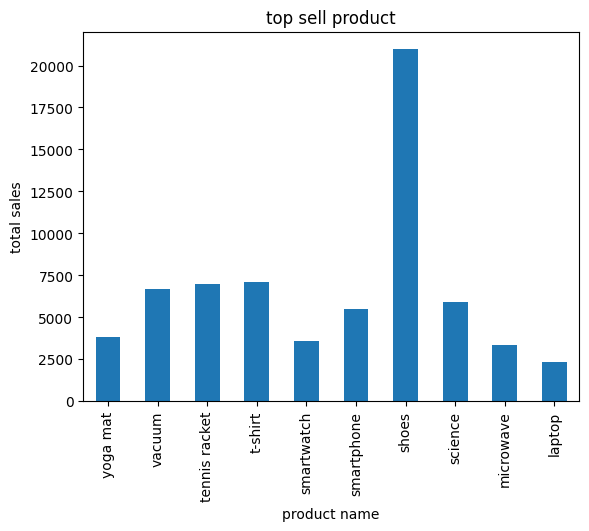

In [58]:
import matplotlib.pyplot as plt
top_products.plot(kind='bar')
plt.xlabel("product name")
plt.ylabel("total sales")
plt.title("top sell product")
plt.show()

Shoes is the highest-selling individual product across the dataset

**CATEGORY ANALYSIS**

In [59]:
category_sales = df.groupby(' Category')['Total'].sum().sort_values(ascending=False)

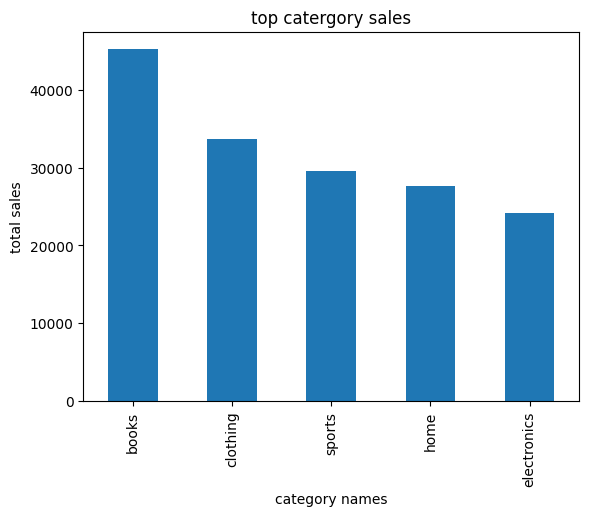

In [60]:
import matplotlib.pyplot as plt
category_sales.plot(kind='bar')
plt.xlabel("category names")
plt.ylabel("total sales")
plt.title("top catergory sales")
plt.show()

The Books category records the highest number of sales among all categories.

**MONTHLY SALES TRENDS**

In [61]:
df['year']=df['Order_Date'].dt.year
df['month']=df['Order_Date'].dt.month
monthly_sales = df.groupby(['year','month'])['Total'].sum().sort_values(ascending=False).head(10)

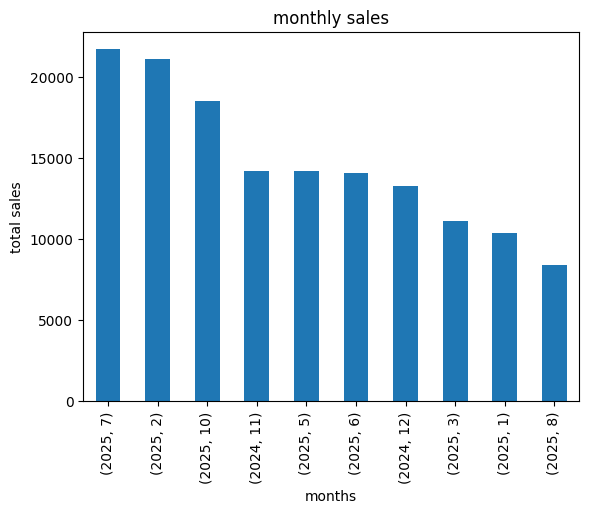

In [62]:
monthly_sales.plot(kind='bar')
plt.xlabel('months')
plt.ylabel('total sales')
plt.title('monthly sales')
plt.show()

Sales are concentrated in specific months of 2025, with around 7 month showing higher sales activity compared to others.

**YEAR-MONTH AND CATEGORY ANALYSIS**

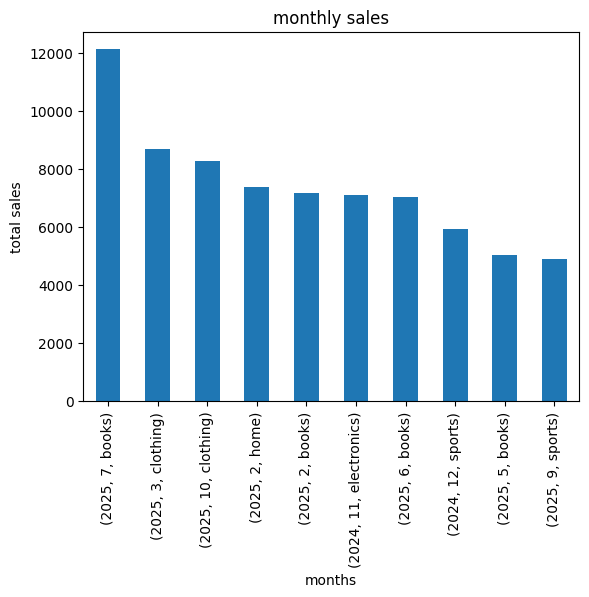

In [63]:
montly_cat=df.groupby(['year','month',' Category'])['Total'].sum().sort_values(ascending=False).head(10)
montly_cat.plot(kind='bar')
plt.xlabel('months')
plt.ylabel('total sales')
plt.title('monthly sales')
plt.show()

The Books category shows strong performance specifically in July 2025.

**ORDER STATUS ANALYSIS**

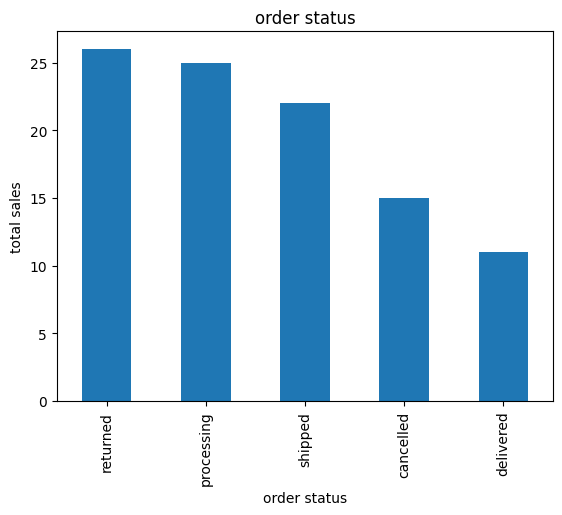

In [64]:
order_status = df['Status'].value_counts()
order_status.plot(kind='bar')
plt.xlabel('order status')
plt.ylabel('total sales')
plt.title('order status')
plt.show()

A noticeable number of orders are returned, suggesting potential issues related to product quality, customer expectations, or delivery accuracy.

**PAYMENT METHOD ANALISIS**

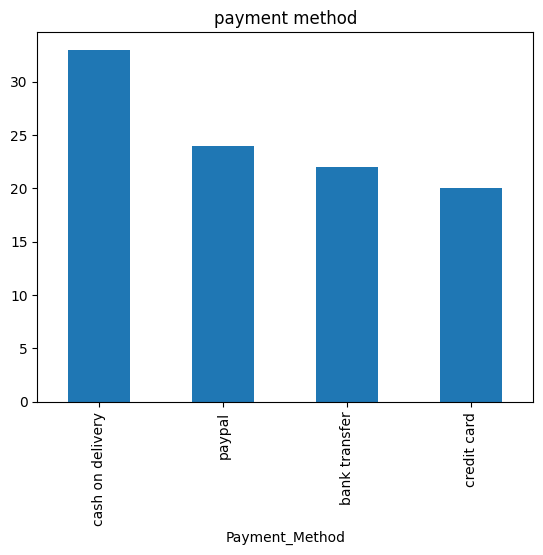

In [65]:
payment = df['Payment_Method'].value_counts()
payment.plot(kind='bar')
plt.title("payment method")
plt.show()

cash on delivery is the most frequently used payment method among customers

**HIGHEST SELLING PRODUCT BY CATEGORY**

In [66]:
cat_product=df.groupby([' Category','Product'])['Total'].sum().sort_values(ascending=False).head(10)
print(cat_product)

 Category  Product      
clothing   shoes            20970.950
books      comics           19142.250
sports     basketball       14844.315
books      fiction          12074.090
home       lamp             11476.900
           blender           8499.600
books      biography         8061.750
sports     tennis racket     7002.900
clothing   t-shirt           5915.300
books      science           5884.080
Name: Total, dtype: float64


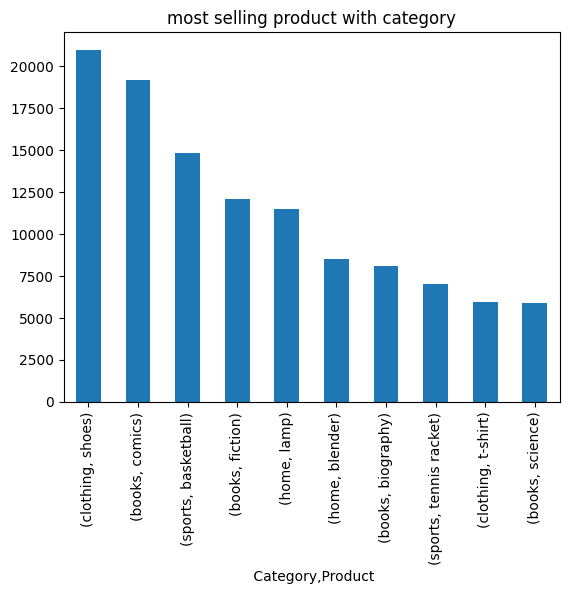

In [67]:
cat_product.plot(kind='bar')
plt.title("most selling product with category")
plt.show()

Within categories, Clothing (Shoes) contributes significantly to sales.

**PRODUCT WITH HIGHEST RETURN RATE**

In [68]:
problem_order = df[df['Status'] == 'returned']
return_rate_per_product = problem_order.groupby('Product')['Status'].size().sort_values(ascending=False)
return_rate_per_category = problem_order.groupby(' Category')['Status'].size().sort_values(ascending=False)
print(return_rate_per_category)
print("-"*50)
print(return_rate_per_product)

 Category
books          10
sports          5
home            5
electronics     4
clothing        2
Name: Status, dtype: int64
--------------------------------------------------
Product
fiction          4
tennis racket    3
lamp             3
blender          2
biography        2
shoes            2
comics           2
science          2
laptop           2
basketball       1
microwave        1
smartphone       1
yoga mat         1
Name: Status, dtype: int64


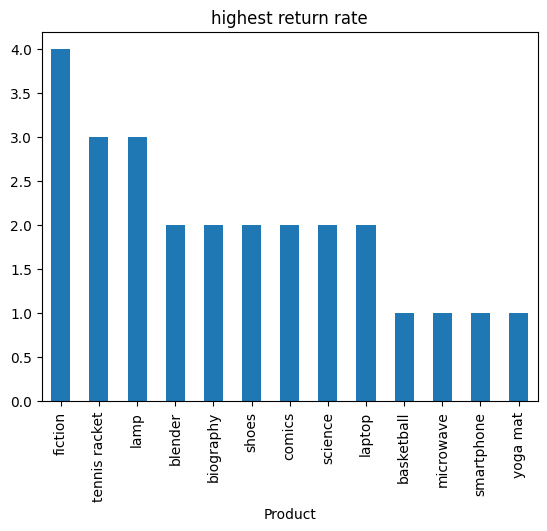

In [69]:
return_rate_per_product.plot(kind='bar')
plt.title("highest return rate")
plt.show()

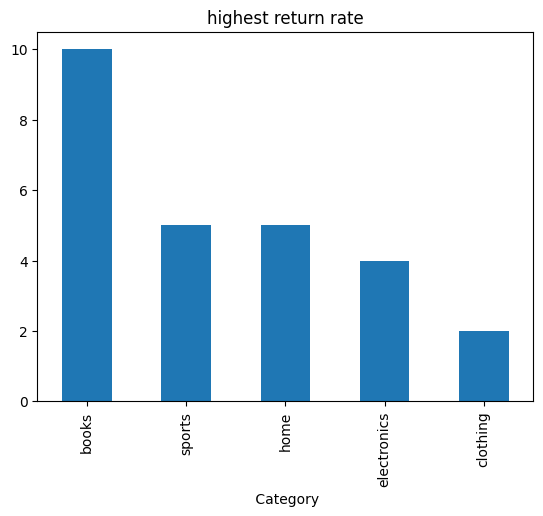

In [70]:
return_rate_per_category.plot(kind='bar')
plt.title("highest return rate")
plt.show()

The product Fiction (Books category) has the highest return rate among all products.

# INSIGHTS
**1. Category vs Product Gap**

The Books category has the highest overall sales, but Shoes is the top-selling individual product.

**2. High Return Issue**

A large number of orders are returned, which suggests there may be issues with product quality or delivery.

**3. Specific Problem Area**

Fiction books have the highest return rate, which may mean customer expectations are not being met.

**4. Seasonal Opportunity**

Sales are highest in July 2025, showing a possible seasonal increase in demand.

**5. Payment Risk Insight**

Cash on Delivery is the most commonly used payment method, which may also be linked to higher return rates.

**6. Revenue Concentration**

Sales depend heavily on a few categories and products, which could be a risk if their demand decreases.


